<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/ND-simulation---Gaussian/3_Flavour_oscillation(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import matplotlib as mpl
mpl.rcParams.update({
    "figure.figsize":   (10, 6),
    "font.size":        16,
    "axes.titlesize":   22,
    "axes.labelsize":   18,
    "xtick.labelsize":  14,
    "ytick.labelsize":  14,
    "legend.fontsize":  16,
    "grid.linewidth":   0.8
})

# Global conversion and matter constants
CONV_KM_TO_INV_EV = 5.067731e9    # km → 1/eV conversion factor
VCC_EARTH_CRUST = 7.6e-14         # Matter potential (eV)

# Standard three-flavor parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0                     # CP-phase (set to 0 or change as needed)
D21 = 7.39e-5                   # eV² (solar)
D31 = 2.525e-3                  # eV² (atmospheric)

# Additional four-flavor parameters
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta14 = 0                     # extra CP-phase
D41 = 1.0                       # eV² (sterile)

# Baseline for Near Detector (ND)
Length_near = 1  # km

# Energy range: 0.5 GeV to 5 GeV (energies in GeV and converted to eV)
energies_GeV = np.linspace(0.5, 5, 50)
energies_eV = energies_GeV * 1e9


Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 741 (delta 110), reused 83 (delta 44), pack-reused 586 (from 1)
Receiving objects: 100% (741/741), 808.67 KiB | 6.17 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/NuOscProbExact/src/NuOscProbExact/src
globaldefs.py       hamiltonians3nu.py  oscprob3nu.py
hamiltonians2nu.py  oscprob2nu.py


In [22]:
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12 * c13 * c14, s12 * c13 * c14, s13 * c14 * np.exp(-1j * delta13), s14 * np.exp(-1j * delta14)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23,
         s24 * c13],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23,
         c24 * s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                            delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2_diag @ np.conjugate(U.T) / (2 * E)

def hamiltonian_4nu_matter(H_vac, E, VCC):
    return H_vac + np.diag([VCC, 0, 0, 0])

def probability_4nu(energy, L, transition='mm', case='vacuum'):
    # energy in eV, L in km
    H_vac = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                                   delta13, delta14, D21, D31, D41, energy)
    if case == 'matter':
        H = hamiltonian_4nu_matter(H_vac, energy, VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':   # μ → μ: use index 1 (muon flavor)
        return np.abs(S[1, 1])**2
    elif transition == 'me': # μ → e: index 0
        return np.abs(S[1, 0])**2
    elif transition == 'mt': # μ → τ: index 2
        return np.abs(S[1, 2])**2
    elif transition == 'ms': # μ → sterile: index 3
        return np.abs(S[1, 3])**2


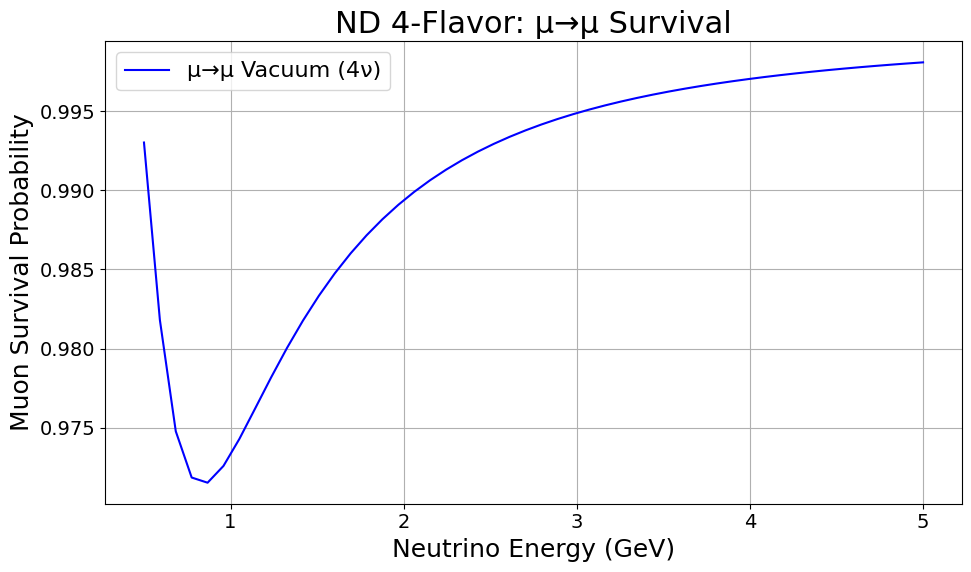

In [23]:
# Compute μ→μ (muon survival) probabilities for 4ν at ND (L = 1 km)
probs_mm_vac_nd = [probability_4nu(E, Length_near, transition='mm', case='vacuum') for E in energies_eV]
probs_mm_mat_nd = [probability_4nu(E, Length_near, transition='mm', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, probs_mm_vac_nd, 'b-', label="μ→μ Vacuum (4ν)")
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("ND 4-Flavor: μ→μ Survival")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


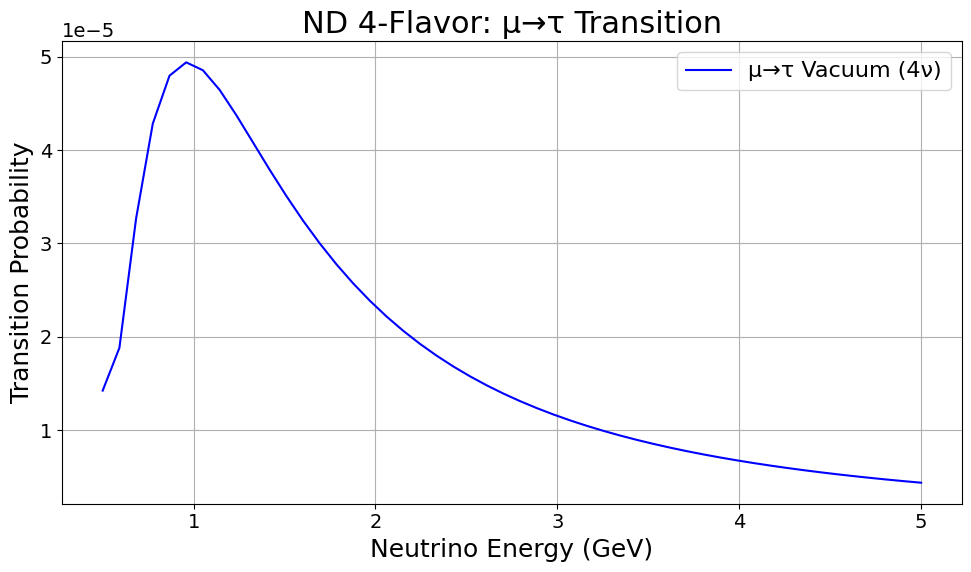

In [24]:
# Compute μ→τ (muon to tau) probabilities for 4ν at ND (L = 1 km)
probs_mt_vac_nd = [probability_4nu(E, Length_near, transition='mt', case='vacuum') for E in energies_eV]
probs_mt_mat_nd = [probability_4nu(E, Length_near, transition='mt', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, probs_mt_vac_nd, 'b-', label="μ→τ Vacuum (4ν)")
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Transition Probability")
plt.title("ND 4-Flavor: μ→τ Transition")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


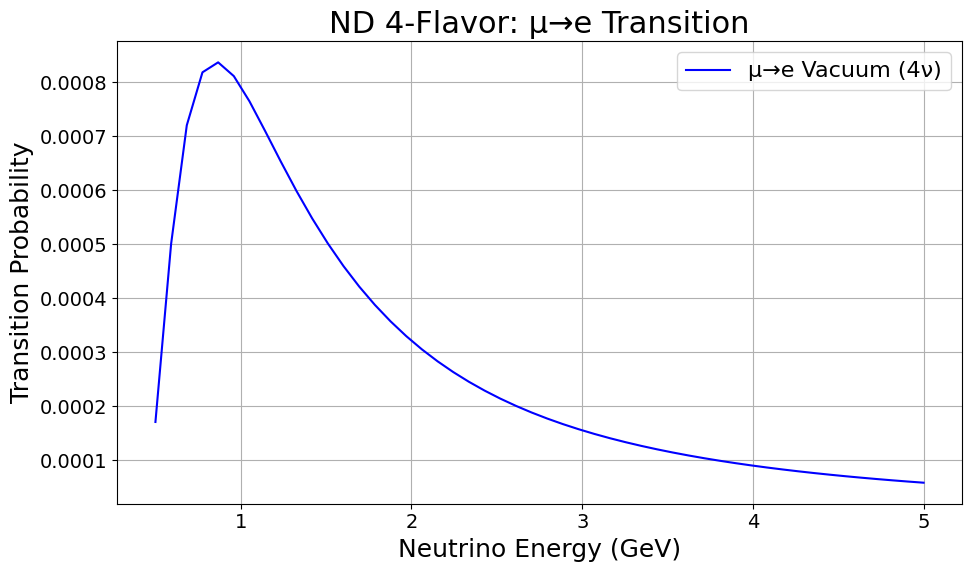

In [25]:
# Compute μ→e (muon to electron) probabilities for 4ν at ND (L = 1 km)
probs_me_vac_nd = [probability_4nu(E, Length_near, transition='me', case='vacuum') for E in energies_eV]
probs_me_mat_nd = [probability_4nu(E, Length_near, transition='me', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, probs_me_vac_nd, 'b-', label="μ→e Vacuum (4ν)")
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Transition Probability")
plt.title("ND 4-Flavor: μ→e Transition")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


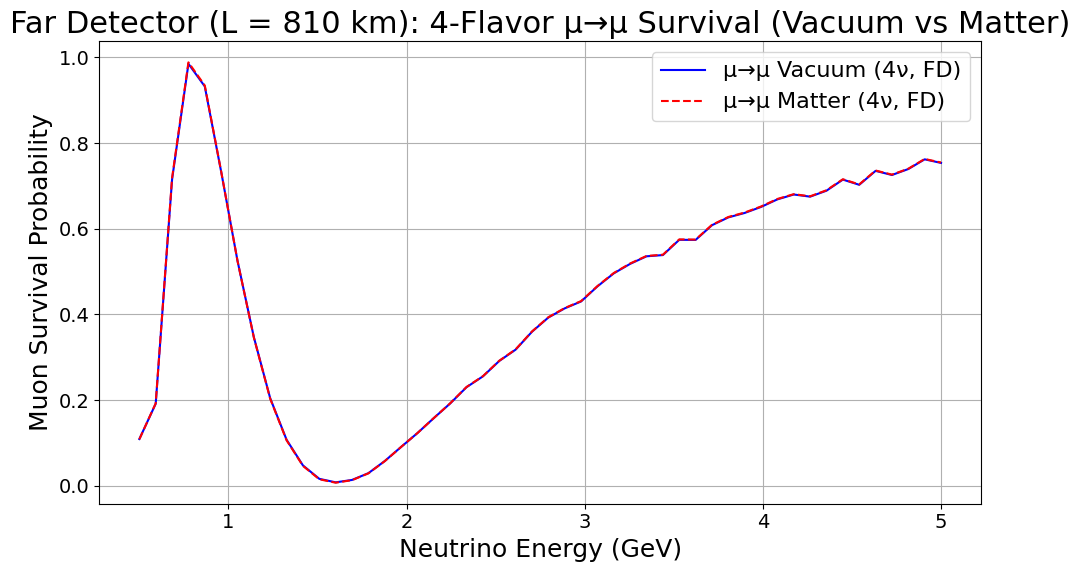

In [26]:
# Set the Far Detector baseline
Length_far = 810  # km

# Define the energy range in GeV and convert to eV
energies_GeV = np.linspace(0.5, 5, 50)
energies_eV = energies_GeV * 1e9

# Compute 4-flavor muon survival probability (νμ → νμ) for the Far Detector,
# in both vacuum and matter conditions.
probs_mm_vac_fd = [probability_4nu(E, Length_far, transition='mm', case='vacuum') for E in energies_eV]
probs_mm_mat_fd = [probability_4nu(E, Length_far, transition='mm', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, probs_mm_vac_fd, 'b-', label="μ→μ Vacuum (4ν, FD)")
plt.plot(energies_GeV, probs_mm_mat_fd, 'r--', label="μ→μ Matter (4ν, FD)")
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("Far Detector (L = 810 km): 4-Flavor μ→μ Survival (Vacuum vs Matter)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


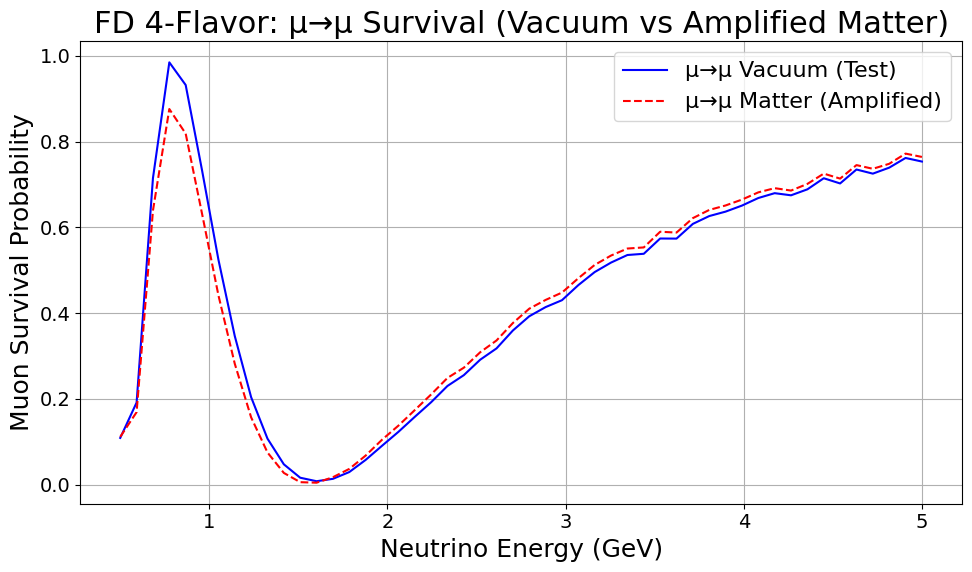

In [27]:
# Temporarily amplify the matter potential for testing:
VCC_test = 10 * VCC_EARTH_CRUST

def probability_4nu_test(energy, L, transition='mm', case='vacuum'):
    H_vac = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                                   delta13, delta14, D21, D31, D41, energy)
    if case == 'matter':
        # Use the amplified potential for testing:
        H = hamiltonian_4nu_matter(H_vac, energy, VCC_test)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1, 1])**2
    elif transition == 'me':
        return np.abs(S[1, 0])**2
    elif transition == 'mt':
        return np.abs(S[1, 2])**2
    elif transition == 'ms':
        return np.abs(S[1, 3])**2

# Now compute with the test function at FD to see a larger matter effect
Length_far = 810  # km
probs_mm_vac_test = [probability_4nu_test(E, Length_far, transition='mm', case='vacuum') for E in energies_eV]
probs_mm_mat_test = [probability_4nu_test(E, Length_far, transition='mm', case='matter') for E in energies_eV]

plt.figure(figsize=(10,6))
plt.plot(energies_GeV, probs_mm_vac_test, 'b-', label="μ→μ Vacuum (Test)")
plt.plot(energies_GeV, probs_mm_mat_test, 'r--', label="μ→μ Matter (Amplified)")
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("FD 4-Flavor: μ→μ Survival (Vacuum vs Amplified Matter)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
# (Assume popt_nd, energies_eV, and your oscillation functions are defined.)
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

# FD Spectrum for a given oscillation model:
#   Here we multiply the ND flux (Gaussian) by the oscillation probability
def fd_spectrum(prob_func, energies_eV, L, **kwargs):
    # prob_func is a function that takes (energy, L, ...) and returns an oscillation probability
    spectrum = []
    for E in energies_eV:
        prob = prob_func(E, L, **kwargs)
        flux = gaussian(E, *popt_nd)
        spectrum.append(flux * prob)
    return np.array(spectrum)


In [29]:
# Import the necessary modules from the NuOscProbExact package.
import oscprob3nu
import hamiltonians3nu
from globaldefs import S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF, CONV_KM_TO_INV_EV, VCC_EARTH_CRUST
import numpy as np

def probability_3nu(E, L, transition='mm', matter=False):
    """
    Compute the three-flavor oscillation probability for a given energy (in eV),
    baseline L (in km), and transition channel.
    The function uses the energy-independent Hamiltonian from hamiltonians3nu,
    then divides by energy.

    Parameters:
      E : float
          Neutrino energy in eV.
      L : float
          Baseline in km.
      transition : str
          'mm' for muon survival, 'me' for μ→e appearance, 'mt' for μ→τ.
      matter : bool
          If True, include matter effects using VCC_EARTH_CRUST.

    Returns:
      float: oscillation probability for the requested transition.
    """
    # Get the energy-independent Hamiltonian in vacuum.
    h_vacuum_energy_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
        S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF)
    # Construct the full Hamiltonian: H = (1/E) * h0
    H = (1.0/E) * h_vacuum_energy_indep
    if matter:
        # Modify H for matter using the routine in hamiltonians3nu.
        H = hamiltonians3nu.hamiltonian_3nu_matter(H, E, VCC_EARTH_CRUST)
    # Compute oscillation probabilities.
    # probabilities_3nu returns [Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt]
    probs = oscprob3nu.probabilities_3nu(H, L * CONV_KM_TO_INV_EV)
    # For a muon neutrino initial state, the ordering is:
    #   index 0: Pee, 1: Pem, 2: Pet, 3: Pme, 4: Pmm, 5: Pmt, ...
    if transition == 'mm':
        return probs[4]
    elif transition == 'me':
        return probs[3]
    elif transition == 'mt':
        return probs[5]


In [30]:
def probability_3nu(E, L, transition='mm', matter=False):
    import numpy as np  # Ensure numpy is imported
    # Get the energy-independent Hamiltonian (convert to np.array)
    h_vacuum_energy_indep = np.array(hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
        S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF))
    # Construct the full Hamiltonian: H = (1/E) * h0
    H = (1.0 / E) * h_vacuum_energy_indep
    if matter:
        # Modify H for matter using the routine in hamiltonians3nu.
        H = hamiltonians3nu.hamiltonian_3nu_matter(H, E, VCC_EARTH_CRUST)
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    # For a muon neutrino, the ordering is: Pee, Pem, Pet, Pme, Pmm, Pmt, ...
    if transition == 'mm':
        return S[1, 1].real**2 + S[1, 1].imag**2
    elif transition == 'me':
        return S[1, 0].real**2 + S[1, 0].imag**2
    elif transition == 'mt':
        return S[1, 2].real**2 + S[1, 2].imag**2


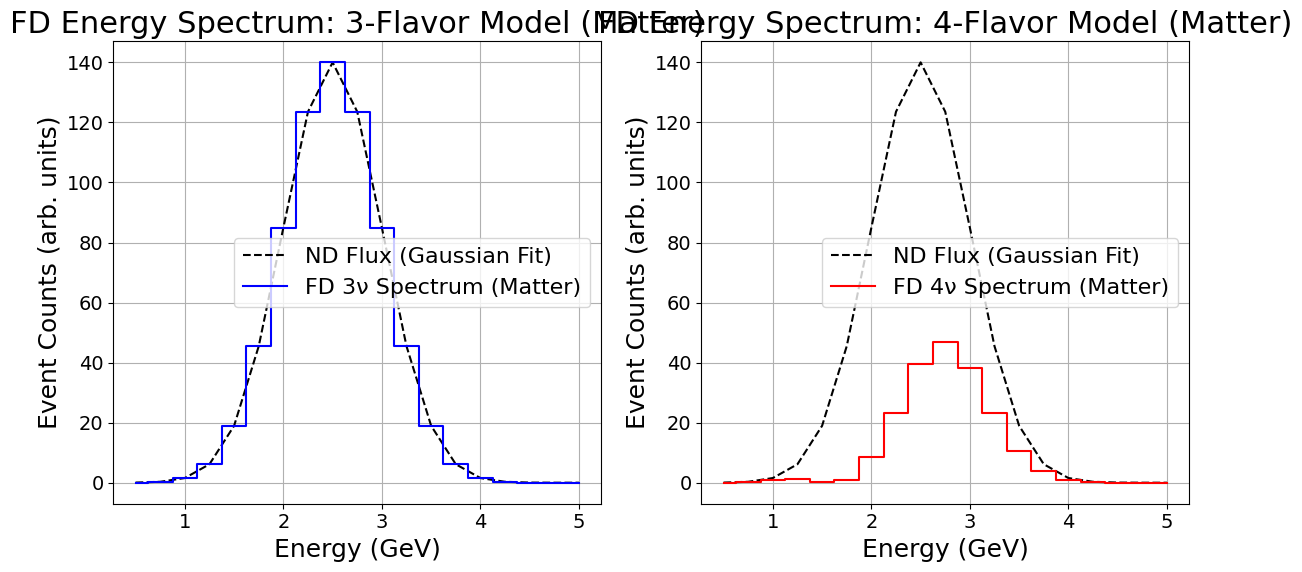

In [31]:
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

# Define a Gaussian function for the ND flux.
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Example ND fit parameters (for flux vs energy in eV) – replace these with your actual values.
popt_nd = [140, 2.5e9, 0.5e9]
# Define bin centers and bin edges (in eV) – here, roughly 0.5 to 5 GeV.
bin_centers = np.linspace(0.5e9, 5e9, 19)
bin_edges = np.linspace(0.5e9, 5e9, 20)

# Define the FD baseline.
Length_far = 810  # km

# Compute the 3ν FD energy spectrum.
# For each energy bin, the "flux" is the ND Gaussian times the oscillation probability.
fd_spec_3nu = np.array([gaussian(E, *popt_nd) * probability_3nu(E, Length_far, transition='mm', matter=True)
                          for E in bin_centers])

# (Assume you have your four-flavor functions defined – for instance, as in our previous snippets.)
# The four-flavor probability function (probability_4nu) is assumed to be defined.
def probability_4nu(energy, L, transition='mm', case='vacuum',
                    theta12=theta12, theta13=theta13, theta23=theta23,
                    theta14=theta14, theta24=theta24, theta34=theta34,
                    delta13=delta13, delta14=delta14, D21=D21, D31=D31, D41=D41):
    H_vac = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34,
                                   delta13, delta14, D21, D31, D41, energy)
    if case == 'matter':
        H = hamiltonian_4nu_matter(H_vac, energy, VCC_EARTH_CRUST)
    else:
        H = H_vac
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1, 1])**2
    elif transition == 'me':
        return np.abs(S[1, 0])**2
    elif transition == 'mt':
        return np.abs(S[1, 2])**2
    elif transition == 'ms':
        return np.abs(S[1, 3])**2

# Compute the 4ν FD energy spectrum (muon survival channel).
fd_spec_4nu = np.array([gaussian(E, *popt_nd) * probability_4nu(E, Length_far, transition='mm', case='matter')
                          for E in bin_centers])

# Plot the spectra in two subplots.
plt.figure(figsize=(12,6))

# 3ν FD Spectrum
plt.subplot(1,2,1)
plt.plot(bin_centers / 1e9, gaussian(bin_centers, *popt_nd), 'k--', label='ND Flux (Gaussian Fit)')
plt.step(bin_centers / 1e9, fd_spec_3nu, where='mid', color='blue', label='FD 3ν Spectrum (Matter)')
plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts (arb. units)")
plt.title("FD Energy Spectrum: 3-Flavor Model (Matter)")
plt.legend()
plt.grid(True)

# 4ν FD Spectrum
plt.subplot(1,2,2)
plt.plot(bin_centers / 1e9, gaussian(bin_centers, *popt_nd), 'k--', label='ND Flux (Gaussian Fit)')
plt.step(bin_centers / 1e9, fd_spec_4nu, where='mid', color='red', label='FD 4ν Spectrum (Matter)')
plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts (arb. units)")
plt.title("FD Energy Spectrum: 4-Flavor Model (Matter)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


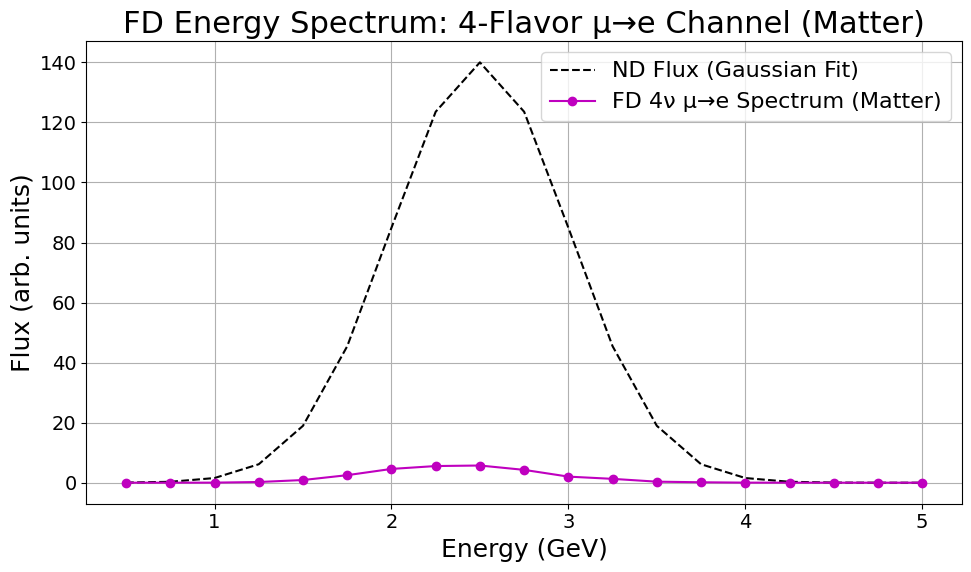

In [32]:
# Compute the 4ν FD energy spectrum for the μ→e channel with matter effects.
fd_spec_4nu_me = np.array([gaussian(E, *popt_nd) * probability_4nu(E, Length_far, transition='me', case='matter')
                             for E in bin_centers])

plt.figure(figsize=(10,6))
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Flux (Gaussian Fit)")
plt.plot(bin_centers/1e9, fd_spec_4nu_me, 'm-', marker='o', label="FD 4ν μ→e Spectrum (Matter)")
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (arb. units)")
plt.title("FD Energy Spectrum: 4-Flavor μ→e Channel (Matter)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


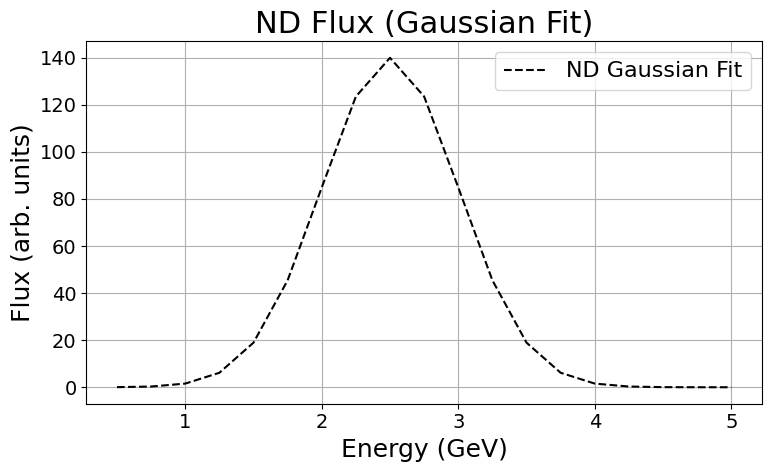

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Global conversion constants (these should match your globaldefs)
CONV_KM_TO_INV_EV = 5.067731e9    # Converts km to inverse eV
VCC_EARTH_CRUST   = 7.6e-14       # Matter potential, e.g., from Earth's crust

# Standard three-flavor parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0                     # CP phase (set to 0; modify to test CP variations)
D21     = 7.39e-5               # eV^2 (solar)
D31     = 2.525e-3              # eV^2 (atmospheric)

# Additional four-flavor parameters
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta14 = 0                     # Extra CP phase for sterile part
D41     = 1.0                   # eV^2 (sterile)

# Near Detector (ND) flux parameters
# For example, these popt_nd are obtained by fitting the ND data to a Gaussian:
popt_nd = [140, 2.5e9, 0.5e9]    # [Amplitude, Mean (eV), Sigma (eV)]
# Define energy bin centers and edges for ND flux (in eV)
bin_centers = np.linspace(0.5e9, 5e9, 19)  # 0.5 to 5 GeV in eV
bin_edges   = np.linspace(0.5e9, 5e9, 20)

# Define the Gaussian function used for the ND flux fit:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

# (Optionally, you can plot the ND flux to verify)
plt.figure(figsize=(8,5))
plt.plot(bin_centers/1e9, gaussian(bin_centers, *popt_nd), 'k--', label="ND Gaussian Fit")
plt.xlabel("Energy (GeV)")
plt.ylabel("Flux (arb. units)")
plt.title("ND Flux (Gaussian Fit)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Define the FD baseline (Far Detector at 810 km)
Length_far = 810

# Define the energy range used for FD spectrum plots (in GeV and convert to eV)
energies_GeV = np.linspace(0.5, 5, 50)
energies_eV = energies_GeV * 1e9


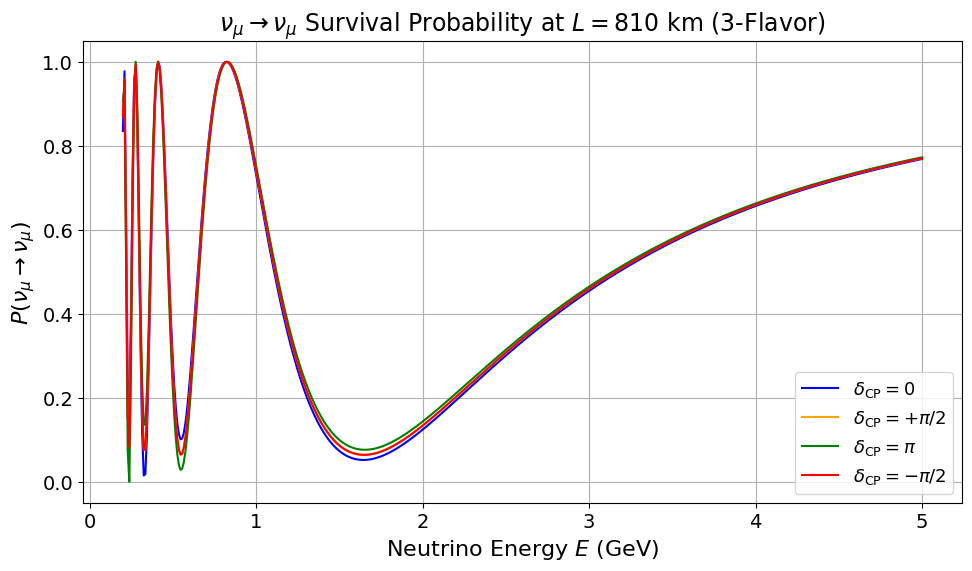

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Mixing angles in radians
theta12 = np.radians(33.44)
theta13 = np.radians(8.57)
theta23 = np.radians(49.2)

# Mass-squared differences (eV²)
dm2_21 = 7.42e-5
dm2_31 = 2.517e-3

# Energy range and baseline
E = np.linspace(0.2, 5.0, 500)  # GeV
L = 810  # km

# Approximate full 3-flavor muon survival probability with CP-phase dependence
def P_mu_to_mu(E, L, dm2_21, dm2_31, theta12, theta13, theta23, delta_cp):
    x31 = 1.27 * dm2_31 * L / E
    x21 = 1.27 * dm2_21 * L / E
    sin2_2theta23 = np.sin(2 * theta23)**2
    sin2_theta13 = np.sin(theta13)**2
    cos2_theta13 = np.cos(theta13)**2
    sin2_theta12 = np.sin(theta12)**2
    sin2_2theta12 = np.sin(2 * theta12)**2

    # Leading term (dominant atmospheric)
    term1 = sin2_2theta23 * cos2_theta13**2 * np.sin(x31)**2

    # Subleading interference term
    A = np.sin(2 * theta12) * cos2_theta13 * np.sin(2 * theta13) * np.sin(2 * theta23)
    interference = A * np.sin(x21) * np.sin(x31) * np.cos(delta_cp)

    return 1 - term1 - interference

# Define δₙₚ values
delta_cps = [0, np.pi/2, np.pi, -np.pi/2]
labels = [r'$\delta_{\rm CP}=0$', r'$\delta_{\rm CP}=+\pi/2$', r'$\delta_{\rm CP}=\pi$', r'$\delta_{\rm CP}=-\pi/2$']
colors = ['blue', 'orange', 'green', 'red']

# Plotting
plt.figure(figsize=(10, 6))
for delta_cp, label, color in zip(delta_cps, labels, colors):
    P = P_mu_to_mu(E, L, dm2_21, dm2_31, theta12, theta13, theta23, delta_cp)
    plt.plot(E, P, label=label, color=color)

plt.xlabel("Neutrino Energy $E$ (GeV)", fontsize=16)
plt.ylabel(r"$P(\nu_\mu \rightarrow \nu_\mu)$", fontsize=16)
plt.title(r"$\nu_\mu \rightarrow \nu_\mu$ Survival Probability at $L=810$ km (3-Flavor)", fontsize=17)
plt.legend(fontsize=13)
plt.grid(True)
plt.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.show()


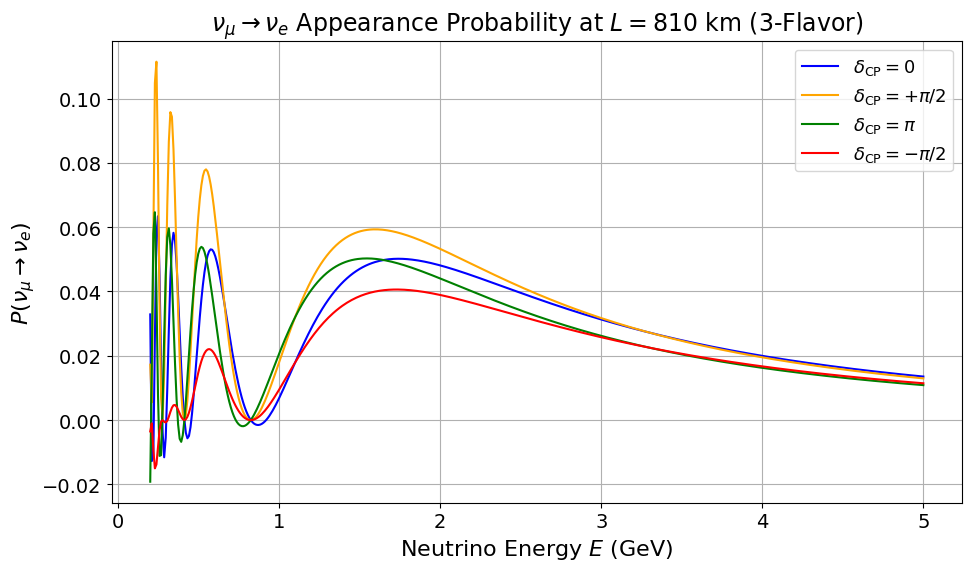

In [34]:
# Mixing angles in radians
theta12 = np.radians(33.44)
theta13 = np.radians(8.57)
theta23 = np.radians(49.2)

# Mass-squared differences (eV²)
dm2_21 = 7.42e-5
dm2_31 = 2.517e-3

# Energy range and baseline
E = np.linspace(0.2, 5.0, 500)  # GeV
L = 810  # km

def P_mu_to_e(E, L, dm2_21, dm2_31, theta12, theta13, theta23, delta_cp):
    x31 = 1.27 * dm2_31 * L / E
    x21 = 1.27 * dm2_21 * L / E
    A = np.sin(2 * theta13) * np.sin(theta23)
    B = np.sin(2 * theta12) * np.cos(theta13) * np.sin(2 * theta13) * np.sin(theta23)
    CP_term = np.cos(delta_cp - x31)
    return A**2 * np.sin(x31)**2 + B * np.sin(x21) * np.sin(x31) * CP_term

delta_cps = [0, np.pi/2, np.pi, -np.pi/2]
labels = [r'$\delta_{\rm CP}=0$', r'$\delta_{\rm CP}=+\pi/2$', r'$\delta_{\rm CP}=\pi$', r'$\delta_{\rm CP}=-\pi/2$']
colors = ['blue', 'orange', 'green', 'red']

plt.figure(figsize=(10, 6))
for delta_cp, label, color in zip(delta_cps, labels, colors):
    P = P_mu_to_e(E, L, dm2_21, dm2_31, theta12, theta13, theta23, delta_cp)
    plt.plot(E, P, label=label, color=color)
plt.xlabel("Neutrino Energy $E$ (GeV)", fontsize=16)
plt.ylabel(r"$P(\nu_\mu \rightarrow \nu_e)$", fontsize=16)
plt.title(r"$\nu_\mu \rightarrow \nu_e$ Appearance Probability at $L=810$ km (3-Flavor)", fontsize=17)
plt.legend(fontsize=13)
plt.grid(True)
plt.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.show()


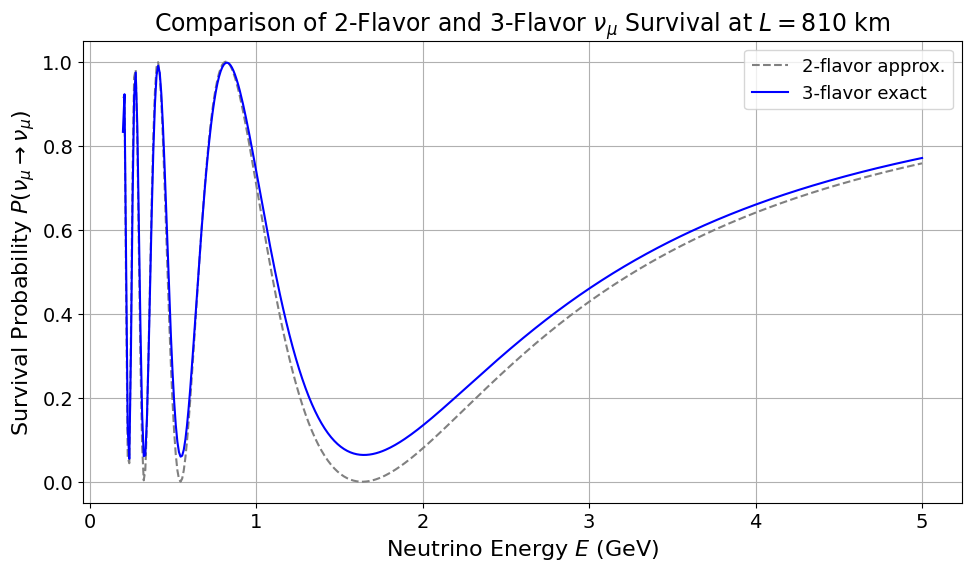

In [35]:
# --- Constants and parameters ---
theta12 = np.radians(33.44)
theta13 = np.radians(8.57)
theta23 = np.radians(49.2)

dm2_21 = 7.42e-5
dm2_31 = 2.517e-3

L = 810  # km
E = np.linspace(0.2, 5.0, 500)  # GeV

# 2-flavour survival probability
def P_mu_to_mu_2f(E, L, dm2, theta):
    x = 1.27 * dm2 * L / E
    return 1 - np.sin(2 * theta)**2 * np.sin(x)**2

# 3-flavour survival probability (approximate expression)
def P_mu_to_mu_3f(E, L, dm2_21, dm2_31, theta12, theta13, theta23):
    x21 = 1.27 * dm2_21 * L / E
    x31 = 1.27 * dm2_31 * L / E
    term1 = np.sin(2 * theta23)**2 * np.cos(theta13)**4 * np.sin(x31)**2
    term2 = np.sin(2 * theta12)**2 * np.sin(theta23)**4 * np.sin(x21)**2
    return 1 - term1 - term2

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(E, P_mu_to_mu_2f(E, L, dm2=2.5e-3, theta=np.radians(45)),
         label='2-flavor approx.', color='gray', linestyle='--')
plt.plot(E, P_mu_to_mu_3f(E, L, dm2_21, dm2_31, theta12, theta13, theta23),
         label='3-flavor exact', color='blue')

plt.xlabel("Neutrino Energy $E$ (GeV)", fontsize=16)
plt.ylabel(r"Survival Probability $P(\nu_\mu \rightarrow \nu_\mu)$", fontsize=16)
plt.title(r"Comparison of 2-Flavor and 3-Flavor $\nu_\mu$ Survival at $L = 810$ km", fontsize=17)
plt.legend(fontsize=13)
plt.grid(True)
plt.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.show()


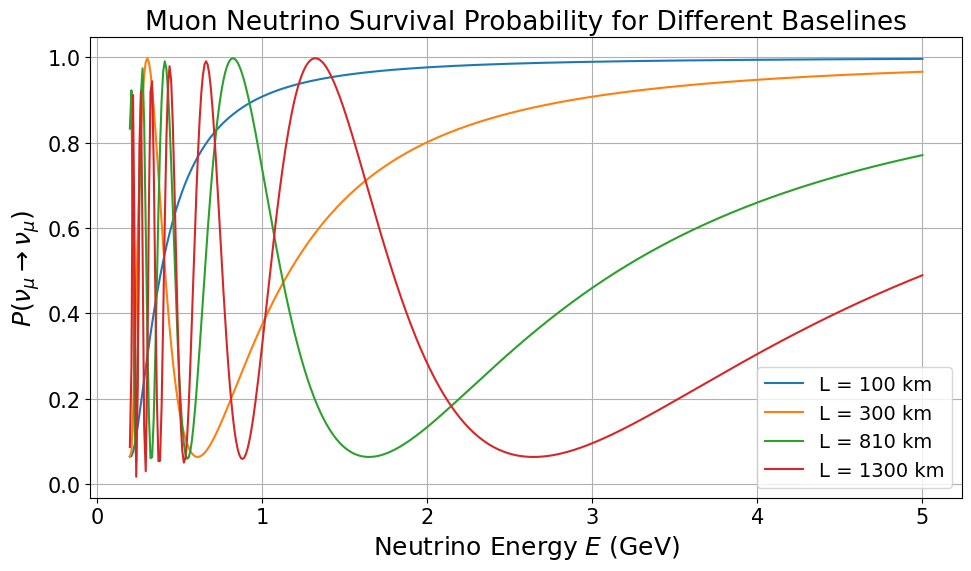

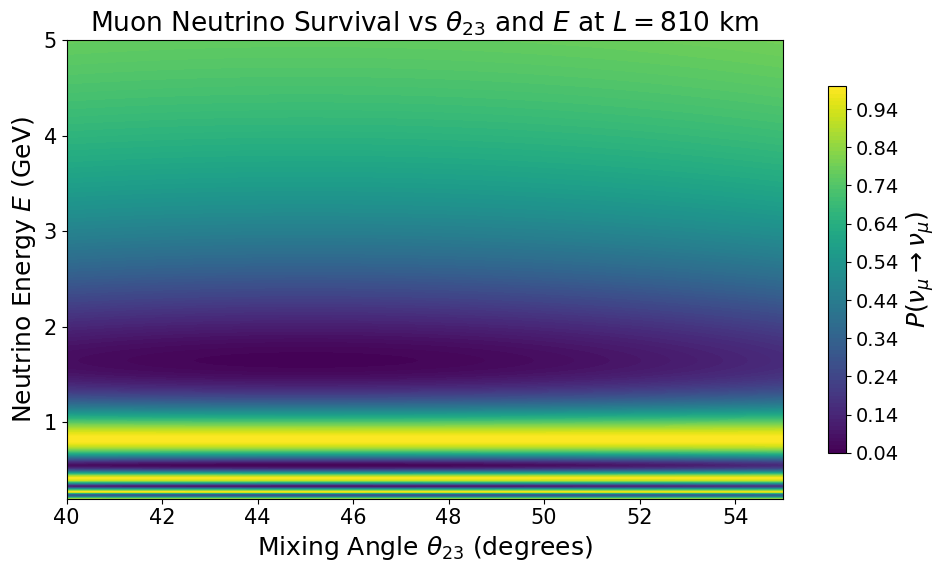

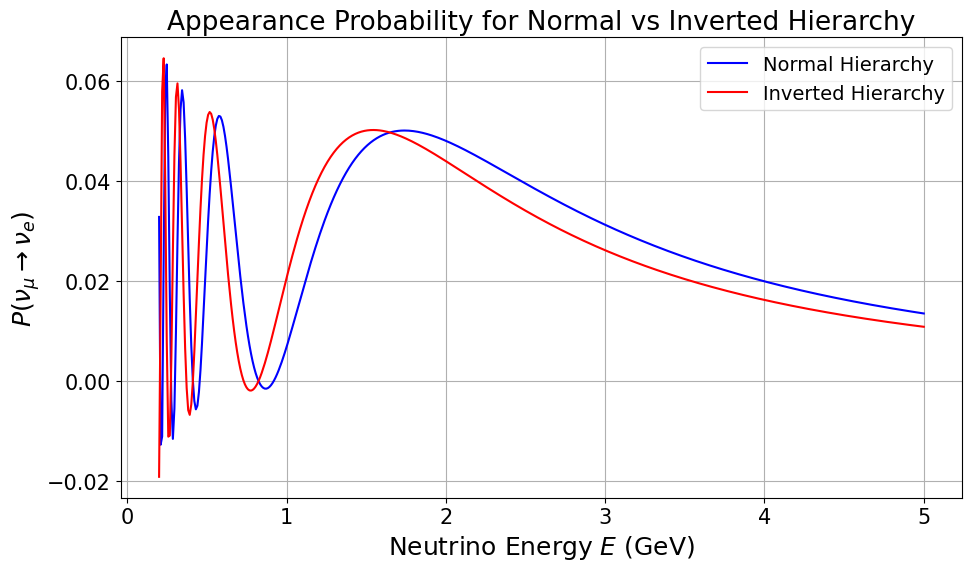

In [36]:
# --- Oscillation parameters ---
theta12 = np.radians(33.44)
theta13 = np.radians(8.57)
theta23 = np.radians(49.2)

dm2_21 = 7.42e-5
dm2_31 = 2.517e-3

# --- General 3-flavour muon survival probability ---
def P_mu_to_mu_3f(E, L, dm2_21, dm2_31, theta12, theta13, theta23):
    x21 = 1.27 * dm2_21 * L / E
    x31 = 1.27 * dm2_31 * L / E
    term1 = np.sin(2 * theta23)**2 * np.cos(theta13)**4 * np.sin(x31)**2
    term2 = np.sin(2 * theta12)**2 * np.sin(theta23)**4 * np.sin(x21)**2
    return 1 - term1 - term2

# --- Graph 1: Muon survival vs energy for various baselines ---
E = np.linspace(0.2, 5.0, 500)
plt.figure(figsize=(10, 6))
for L in [100, 300, 810, 1300]:  # km
    P = P_mu_to_mu_3f(E, L, dm2_21, dm2_31, theta12, theta13, theta23)
    plt.plot(E, P, label=f'L = {L} km')

plt.xlabel("Neutrino Energy $E$ (GeV)", fontsize=18)
plt.ylabel(r"$P(\nu_\mu \rightarrow \nu_\mu)$", fontsize=18)
plt.title("Muon Neutrino Survival Probability for Different Baselines", fontsize=19)
plt.legend(fontsize=14)
plt.grid(True)
plt.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.show()

# --- Graph 2: Heatmap of survival probability vs θ23 and E at fixed L ---
theta23_vals = np.radians(np.linspace(40, 55, 200))
E_vals = np.linspace(0.2, 5.0, 200)
TH23, EE = np.meshgrid(theta23_vals, E_vals)
prob_map = P_mu_to_mu_3f(EE, 810, dm2_21, dm2_31, theta12, theta13, TH23)

plt.figure(figsize=(10, 6))
c = plt.contourf(np.degrees(TH23), EE, prob_map, levels=100, cmap='viridis')
plt.colorbar(c, label=r"$P(\nu_\mu \rightarrow \nu_\mu)$", shrink=0.8)
plt.xlabel(r"Mixing Angle $\theta_{23}$ (degrees)", fontsize=18)
plt.ylabel("Neutrino Energy $E$ (GeV)", fontsize=18)
plt.title(r"Muon Neutrino Survival vs $\theta_{23}$ and $E$ at $L=810$ km", fontsize=19)
plt.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.show()

# --- Graph 3: νμ → νe vs energy, NH vs IH ---
def P_mu_to_e(E, L, dm2_21, dm2_31, theta12, theta13, theta23, delta_cp):
    x31 = 1.27 * dm2_31 * L / E
    x21 = 1.27 * dm2_21 * L / E
    A = np.sin(2 * theta13) * np.sin(theta23)
    B = np.sin(2 * theta12) * np.cos(theta13) * np.sin(2 * theta13) * np.sin(theta23)
    CP_term = np.cos(delta_cp - x31)
    return A**2 * np.sin(x31)**2 + B * np.sin(x21) * np.sin(x31) * CP_term

plt.figure(figsize=(10, 6))
delta_cp = 0  # Fixed CP phase
plt.plot(E, P_mu_to_e(E, 810, dm2_21, +2.517e-3, theta12, theta13, theta23, delta_cp),
         label='Normal Hierarchy', color='blue')
plt.plot(E, P_mu_to_e(E, 810, dm2_21, -2.517e-3, theta12, theta13, theta23, delta_cp),
         label='Inverted Hierarchy', color='red')

plt.xlabel("Neutrino Energy $E$ (GeV)", fontsize=18)
plt.ylabel(r"$P(\nu_\mu \rightarrow \nu_e)$", fontsize=18)
plt.title(r"Appearance Probability for Normal vs Inverted Hierarchy", fontsize=19)
plt.legend(fontsize=14)
plt.grid(True)
plt.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.show()


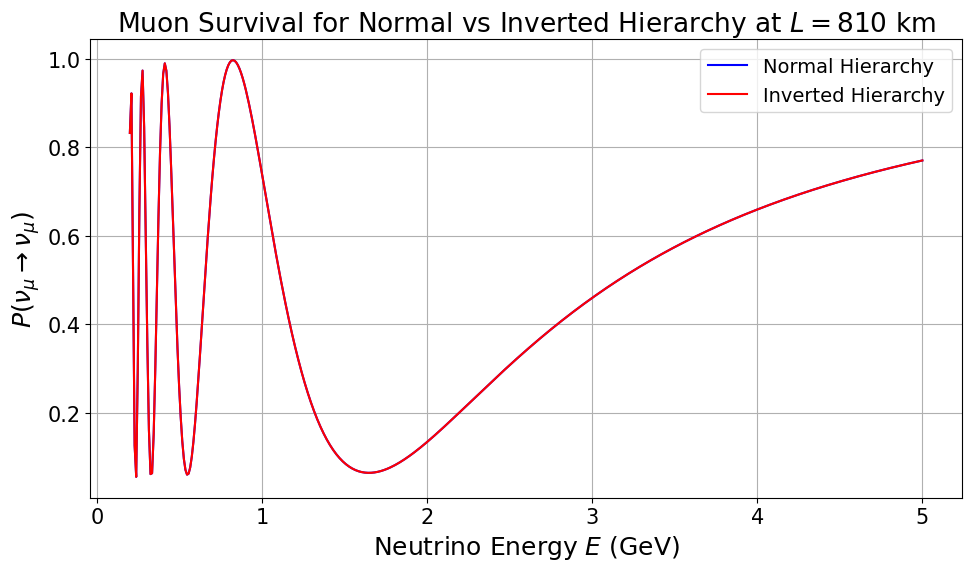

In [40]:
# --- Graph 3: Muon survival vs energy for NH vs IH ---
plt.figure(figsize=(10, 6))
delta_cp = 0  # Not used in survival channel in this simplified formula
plt.plot(E, P_mu_to_mu_3f(E, 810, dm2_21, +2.517e-3, theta12, theta13, theta23),
         label='Normal Hierarchy', color='blue')
plt.plot(E, P_mu_to_mu_3f(E, 810, dm2_21, -2.517e-3, theta12, theta13, theta23),
         label='Inverted Hierarchy', color='red')

plt.xlabel("Neutrino Energy $E$ (GeV)", fontsize=18)
plt.ylabel(r"$P(\nu_\mu \rightarrow \nu_\mu)$", fontsize=18)
plt.title(r"Muon Survival for Normal vs Inverted Hierarchy at $L=810$ km", fontsize=19)
plt.legend(fontsize=14)
plt.grid(True)
plt.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.show()

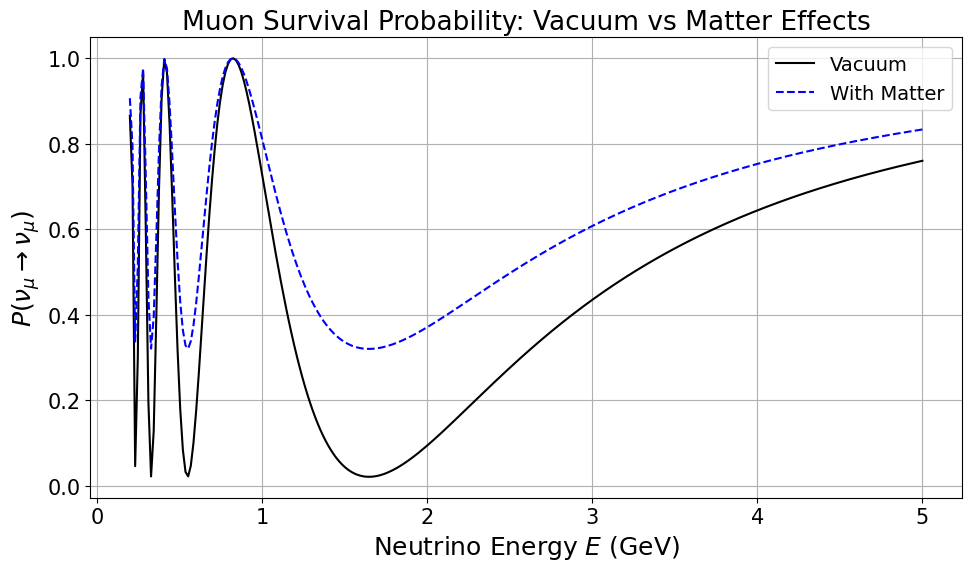

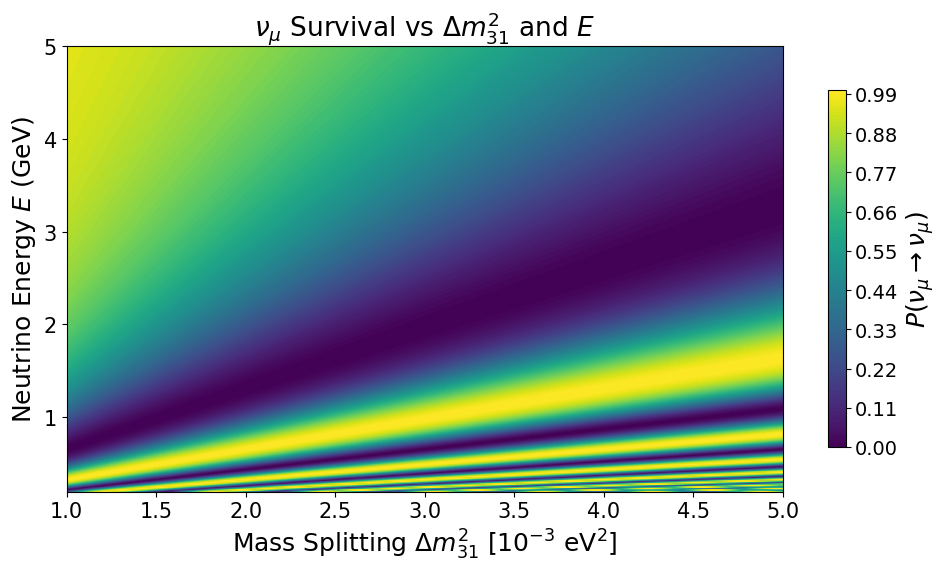

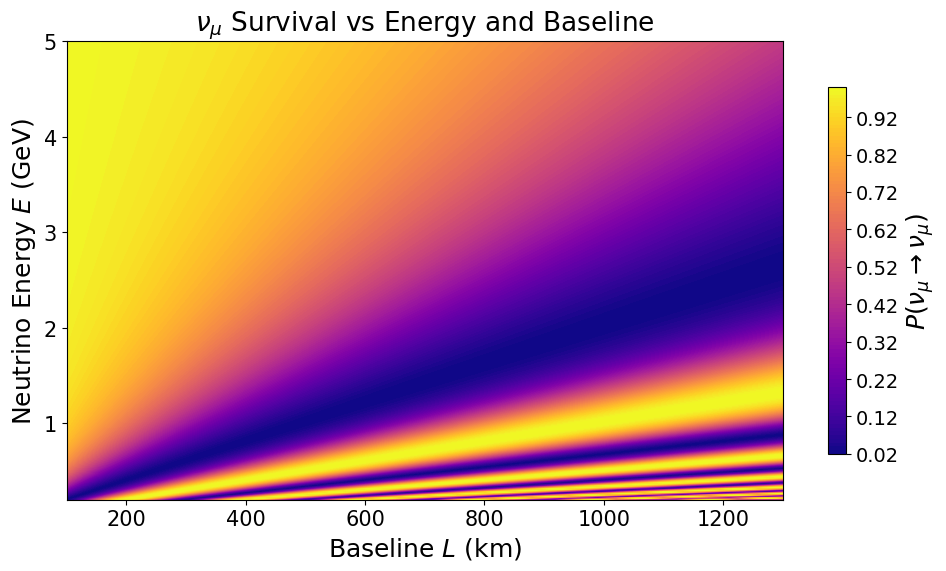

In [37]:
# Oscillation parameters
theta12 = np.radians(33.44)
theta13 = np.radians(8.57)
theta23 = np.radians(49.2)

dm2_21 = 7.42e-5
dm2_31 = 2.517e-3

# Energy and baseline setup
E = np.linspace(0.2, 5.0, 300)
L = 810  # km

# --- 1. Muon Survival: Vacuum vs Matter Effects (Approximation) ---
def P_mu_to_mu_matter(E, L, dm2_31, theta23, V=0):
    x = 1.27 * dm2_31 * L / E
    sin2_2theta = np.sin(2 * theta23)**2 / (1 + V)**2  # Approximate suppression
    return 1 - sin2_2theta * np.sin(x)**2

plt.figure(figsize=(10, 6))
plt.plot(E, P_mu_to_mu_matter(E, L, dm2_31, theta23, V=0), label="Vacuum", color='black')
plt.plot(E, P_mu_to_mu_matter(E, L, dm2_31, theta23, V=0.2), label="With Matter", color='blue', linestyle='--')
plt.xlabel("Neutrino Energy $E$ (GeV)", fontsize=18)
plt.ylabel(r"$P(\nu_\mu \rightarrow \nu_\mu)$", fontsize=18)
plt.title("Muon Survival Probability: Vacuum vs Matter Effects", fontsize=19)
plt.legend(fontsize=14)
plt.grid(True)
plt.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.show()

# --- 2. Contour Plot: P(νμ→νμ) vs Δm²31 and E ---
dm2_range = np.linspace(1e-3, 5e-3, 200)
DM2, EE = np.meshgrid(dm2_range, E)
def P_mu_mu_grid(E, L, dm2, theta):
    x = 1.27 * dm2 * L / E
    return 1 - np.sin(2 * theta)**2 * np.sin(x)**2
grid = P_mu_mu_grid(EE, L, DM2, np.radians(45))

plt.figure(figsize=(10, 6))
cp = plt.contourf(DM2 * 1e3, EE, grid, levels=100, cmap='viridis')  # Convert x-axis to 10⁻³ eV²
plt.colorbar(cp, label=r"$P(\nu_\mu \rightarrow \nu_\mu)$", shrink=0.8)
plt.xlabel(r"Mass Splitting $\Delta m^2_{31}$ [$10^{-3}$ eV$^2$]", fontsize=18)
plt.ylabel("Neutrino Energy $E$ (GeV)", fontsize=18)
plt.title(r"$\nu_\mu$ Survival vs $\Delta m^2_{31}$ and $E$", fontsize=19)
plt.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.show()

# --- 3. Heatmap: P(νμ→νμ) vs Energy and Baseline ---
L_vals = np.linspace(100, 1300, 300)
LL, EE = np.meshgrid(L_vals, E)
grid2 = P_mu_to_mu_matter(EE, LL, dm2_31, theta23, V=0)

plt.figure(figsize=(10, 6))
cp2 = plt.contourf(LL, EE, grid2, levels=100, cmap='plasma')
plt.colorbar(cp2, label=r"$P(\nu_\mu \rightarrow \nu_\mu)$", shrink=0.8)
plt.xlabel("Baseline $L$ (km)", fontsize=18)
plt.ylabel("Neutrino Energy $E$ (GeV)", fontsize=18)
plt.title(r"$\nu_\mu$ Survival vs Energy and Baseline", fontsize=19)
plt.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.show()


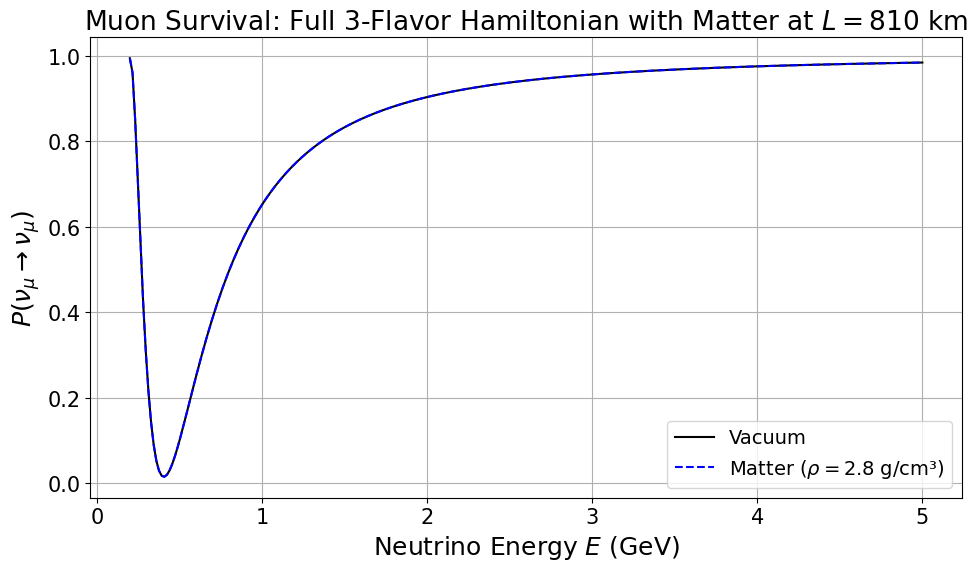

In [38]:

# --- PMNS matrix construction ---
def PMNS_matrix(theta12, theta13, theta23, delta_cp):
    c12, c13, c23 = np.cos([theta12, theta13, theta23])
    s12, s13, s23 = np.sin([theta12, theta13, theta23])
    e_idelta = np.exp(-1j * delta_cp)

    U = np.array([
        [c12 * c13, s12 * c13, s13 * e_idelta],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta_cp), c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta_cp), c13 * s23],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta_cp), -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta_cp), c13 * c23]
    ])
    return U

# --- Full 3-flavor survival probability in matter ---
def P_mu_to_mu_matter_exact(E, L, dm2_21, dm2_31, theta12, theta13, theta23, delta_cp, rho):
    # Constants
    GF = 1.1663787e-5  # Fermi constant [GeV^-2]
    Ne = rho * 1.0  # electron density (g/cm³) ~ nucleon density
    V = np.sqrt(2) * GF * Ne * 1e-9  # eV

    # Build PMNS and mass matrix
    U = PMNS_matrix(theta12, theta13, theta23, delta_cp)
    M2 = np.diag([0, dm2_21, dm2_31])
    H_vac = U @ M2 @ U.conj().T / (2 * E)
    H_mat = H_vac + np.diag([V, 0, 0])

    # Time evolution
    H = H_mat * 1.27 * L
    U_t = expm(-1j * H)
    nu_mu = np.array([0, 1, 0])
    nu_t = U_t @ nu_mu
    return np.abs(nu_t[1])**2  # survival probability

# --- Parameters ---
theta12 = np.radians(33.44)
theta13 = np.radians(8.57)
theta23 = np.radians(49.2)
delta_cp = 0
dm2_21 = 7.42e-5
dm2_31 = 2.517e-3
L = 810  # km
E = np.linspace(0.2, 5.0, 300)  # GeV

# --- Compute survival probabilities ---
P_vac = [P_mu_to_mu_matter_exact(e, L, dm2_21, dm2_31, theta12, theta13, theta23, delta_cp, rho=0) for e in E]
P_mat = [P_mu_to_mu_matter_exact(e, L, dm2_21, dm2_31, theta12, theta13, theta23, delta_cp, rho=2.8) for e in E]

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.plot(E, P_vac, label="Vacuum", color='black')
plt.plot(E, P_mat, label="Matter ($\\rho = 2.8$ g/cm³)", color='blue', linestyle='--')
plt.xlabel("Neutrino Energy $E$ (GeV)", fontsize=18)
plt.ylabel(r"$P(\nu_\mu \rightarrow \nu_\mu)$", fontsize=18)
plt.title(r"Muon Survival: Full 3-Flavor Hamiltonian with Matter at $L=810$ km", fontsize=19)
plt.legend(fontsize=14)
plt.grid(True)
plt.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.show()
